# Chapter 9 — Why Subword Tokenization Exists

Chapter 7 used characters to keep the vocabulary small and preserve text exactly.

Chapter 8 used word-like tokens to shorten sequences, but exposed vocabulary growth and unknown-word problems.

This chapter develops the compromise between those two choices.

By the end of the chapter, you will be able to:

- explain the competing costs of character-level and word-level tokenization;
- define a subword token without assuming it is a linguistic unit;
- use known pieces to represent words absent from a whole-word vocabulary;
- compare all three tokenization levels on the same text; and
- explain what a learned subword tokenizer must decide.

The tokenizer here is hand-written for teaching and is not production-ready.

## The Tradeoff We Need to Resolve

A **sequence length** is the number of tokens used to represent a text.

A **vocabulary size** is the number of distinct token types a tokenizer recognizes.

Character tokenization usually uses a modest vocabulary and many sequence positions.

Word-level tokenization usually uses fewer sequence positions but needs many distinct word forms.

A **subword token** is a reusable piece that can be smaller than a word and larger than one character.

For example, a tokenizer might represent related forms with shared pieces:

```text
looked      -> look + ed
looking     -> look + ing
unhappy     -> un + happy
happiness   -> happi + ness
unhappiness -> un + happi + ness
```

The spelling change matters: `happiness` contains `happi`, not the exact string `happy`.

Tokenization operates on the text that is present rather than silently rewriting its spelling.

## Use a Small Comparison Fixture

The examples contain related forms that a whole-word vocabulary would treat separately.

They are a teaching fixture rather than a training corpus.

In [1]:
example_words = [
    "look",
    "looks",
    "looked",
    "looking",
    "happy",
    "unhappy",
    "happiness",
    "unhappiness",
]

example_sentences = [
    "the cat looked happy.",
    "the dog looks unhappy.",
    "the child was looking at happiness.",
]

print("Words:", example_words)
print("Sentences:")
for sentence in example_sentences:
    print(" ", sentence)

Words: ['look', 'looks', 'looked', 'looking', 'happy', 'unhappy', 'happiness', 'unhappiness']
Sentences:
  the cat looked happy.
  the dog looks unhappy.
  the child was looking at happiness.


## Review the Two Extremes

Character tokenization can represent these words from individual characters, but its sequences grow with spelling length.

The word-and-punctuation tokenizer from Chapter 8 usually represents each example word with one token.

In [2]:
def tokenize_characters(text: str) -> list[str]:
    return list(text)


for word in example_words:
    character_tokens = tokenize_characters(word)
    print(f"{word:<15} {len(character_tokens):>2} tokens  {character_tokens}")

look             4 tokens  ['l', 'o', 'o', 'k']
looks            5 tokens  ['l', 'o', 'o', 'k', 's']
looked           6 tokens  ['l', 'o', 'o', 'k', 'e', 'd']
looking          7 tokens  ['l', 'o', 'o', 'k', 'i', 'n', 'g']
happy            5 tokens  ['h', 'a', 'p', 'p', 'y']
unhappy          7 tokens  ['u', 'n', 'h', 'a', 'p', 'p', 'y']
happiness        9 tokens  ['h', 'a', 'p', 'p', 'i', 'n', 'e', 's', 's']
unhappiness     11 tokens  ['u', 'n', 'h', 'a', 'p', 'p', 'i', 'n', 'e', 's', 's']


In [3]:
import re


def tokenize_words_and_punctuation(text: str) -> list[str]:
    return re.findall(r"[A-Za-z]+|[0-9]+|[^\w\s]", text)


for sentence in example_sentences:
    print(tokenize_words_and_punctuation(sentence))

['the', 'cat', 'looked', 'happy', '.']
['the', 'dog', 'looks', 'unhappy', '.']
['the', 'child', 'was', 'looking', 'at', 'happiness', '.']


The word-level output is compact, but `look`, `looks`, `looked`, and `looking` are unrelated vocabulary entries to this tokenizer.

Its splitting rule does not reveal their shared text.

## Reproduce the Unknown-Word Problem

Suppose a whole-word vocabulary comes from only one short sentence.

Words absent from that sentence cannot receive their own IDs.

In [4]:
training_text = "the cat looked happy."
training_word_tokens = tokenize_words_and_punctuation(training_text)
word_vocabulary = sorted(set(training_word_tokens))

new_sentence = "the dog looks unhappy."
new_word_tokens = tokenize_words_and_punctuation(new_sentence)

print("Vocabulary:", word_vocabulary)
print("New tokens:")
for token in new_word_tokens:
    status = "known" if token in word_vocabulary else "unknown"
    print(f"  {token!r:<12} {status}")

Vocabulary: ['.', 'cat', 'happy', 'looked', 'the']
New tokens:
  'the'        known
  'dog'        unknown
  'looks'      unknown
  'unhappy'    unknown
  '.'          known


A single unknown token allows encoding to continue, but every unseen word collapses to the same representation.

The next cell makes that information loss explicit.

In [5]:
UNKNOWN_TOKEN = "<unknown>"
word_vocabulary_with_unknown = [UNKNOWN_TOKEN, *word_vocabulary]
word_token_to_id = {
    token: token_id for token_id, token in enumerate(word_vocabulary_with_unknown)
}
id_to_word_token = {token_id: token for token, token_id in word_token_to_id.items()}


def encode_words_with_unknown(
    tokens: list[str],
    token_to_id: dict[str, int],
    unknown_token: str,
) -> list[int]:
    unknown_token_id = token_to_id[unknown_token]
    return [token_to_id.get(token, unknown_token_id) for token in tokens]


word_token_ids = encode_words_with_unknown(
    new_word_tokens,
    word_token_to_id,
    UNKNOWN_TOKEN,
)
decoded_word_tokens = [id_to_word_token[token_id] for token_id in word_token_ids]

print("Original tokens:", new_word_tokens)
print("Decoded tokens: ", decoded_word_tokens)

Original tokens: ['the', 'dog', 'looks', 'unhappy', '.']
Decoded tokens:  ['the', '<unknown>', '<unknown>', '<unknown>', '.']


`dog`, `looks`, and `unhappy` are now indistinguishable after decoding.

Subwords help when an unseen whole word can be composed from pieces the tokenizer already knows.

## Define a Hand-Written Subword Vocabulary

The toy vocabulary contains a mixture of complete words, punctuation, and reusable word pieces.

It is intentionally lowercase and therefore cannot preserve capitalization.

Real subword vocabularies are normally learned from data rather than selected by hand.

In [6]:
subword_vocabulary = [
    UNKNOWN_TOKEN,
    ".",
    "the",
    "cat",
    "dog",
    "child",
    "was",
    "at",
    "look",
    "s",
    "ed",
    "ing",
    "un",
    "happy",
    "happi",
    "ness",
]

subword_to_id = {
    subword: subword_id for subword_id, subword in enumerate(subword_vocabulary)
}
id_to_subword = {subword_id: subword for subword, subword_id in subword_to_id.items()}

for subword, subword_id in subword_to_id.items():
    print(f"{subword_id:>2}: {subword!r}")

 0: '<unknown>'
 1: '.'
 2: 'the'
 3: 'cat'
 4: 'dog'
 5: 'child'
 6: 'was'
 7: 'at'
 8: 'look'
 9: 's'
10: 'ed'
11: 'ing'
12: 'un'
13: 'happy'
14: 'happi'
15: 'ness'


## Split a Word with Greedy Longest Match

At each position, the toy algorithm chooses the longest vocabulary piece that begins there.

If no piece matches, it emits `<unknown>` for the unsupported remainder of the word.

This deterministic rule is easy to inspect, but greedy matching is only one possible segmentation strategy and is not guaranteed to find a globally best split.

In [7]:
def split_word_into_subwords(
    word: str,
    vocabulary: list[str],
    unknown_token: str,
) -> list[str]:
    vocabulary_set = set(vocabulary)
    pieces = []
    position = 0

    while position < len(word):
        longest_match = None

        for end_position in range(len(word), position, -1):
            candidate = word[position:end_position]
            if candidate in vocabulary_set and candidate != unknown_token:
                longest_match = candidate
                break

        if longest_match is None:
            pieces.append(unknown_token)
            break

        pieces.append(longest_match)
        position += len(longest_match)

    return pieces

In [8]:
for word in example_words:
    pieces = split_word_into_subwords(
        word,
        subword_vocabulary,
        UNKNOWN_TOKEN,
    )
    print(f"{word:<15} -> {pieces}")

look            -> ['look']
looks           -> ['look', 's']
looked          -> ['look', 'ed']
looking         -> ['look', 'ing']
happy           -> ['happy']
unhappy         -> ['un', 'happy']
happiness       -> ['happi', 'ness']
unhappiness     -> ['un', 'happi', 'ness']


The output shares `look` across four forms and reuses `un`, `happi`, and `ness` where their exact strings occur.

The split is determined entirely by the available vocabulary and the longest-match rule.

## Tokenize Complete Sentences

The sentence tokenizer first separates word-like tokens from punctuation.

Known whole tokens remain intact, while other alphabetic tokens are split into subwords.

Lowercasing and discarded whitespace make this example lossy by design.

In [9]:
def tokenize_with_handwritten_subwords(
    text: str,
    vocabulary: list[str],
    unknown_token: str,
) -> list[str]:
    initial_tokens = tokenize_words_and_punctuation(text.lower())
    subword_tokens = []

    for token in initial_tokens:
        if token in vocabulary:
            subword_tokens.append(token)
        elif token.isalpha():
            subword_tokens.extend(
                split_word_into_subwords(token, vocabulary, unknown_token)
            )
        else:
            subword_tokens.append(unknown_token)

    return subword_tokens


for sentence in example_sentences:
    print(sentence)
    print(
        tokenize_with_handwritten_subwords(
            sentence,
            subword_vocabulary,
            UNKNOWN_TOKEN,
        )
    )
    print()

the cat looked happy.
['the', 'cat', 'look', 'ed', 'happy', '.']

the dog looks unhappy.
['the', 'dog', 'look', 's', 'un', 'happy', '.']

the child was looking at happiness.
['the', 'child', 'was', 'look', 'ing', 'at', 'happi', 'ness', '.']



## Compare All Three Token Sequences

One sentence now shows the central compromise directly.

The whole-word sequence is shortest, but its `unhappiness` token would be unknown to a vocabulary that had not seen that exact word.

In [10]:
comparison_sentence = "the child was looking at unhappiness."

character_tokens = tokenize_characters(comparison_sentence)
word_tokens = tokenize_words_and_punctuation(comparison_sentence)
subword_tokens = tokenize_with_handwritten_subwords(
    comparison_sentence,
    subword_vocabulary,
    UNKNOWN_TOKEN,
)

tokenization_results = [
    ("characters", character_tokens),
    ("whole words", word_tokens),
    ("subwords", subword_tokens),
]

for method_name, tokens in tokenization_results:
    print(f"{method_name} ({len(tokens)} tokens)")
    print(tokens)
    print()

characters (37 tokens)
['t', 'h', 'e', ' ', 'c', 'h', 'i', 'l', 'd', ' ', 'w', 'a', 's', ' ', 'l', 'o', 'o', 'k', 'i', 'n', 'g', ' ', 'a', 't', ' ', 'u', 'n', 'h', 'a', 'p', 'p', 'i', 'n', 'e', 's', 's', '.']

whole words (7 tokens)
['the', 'child', 'was', 'looking', 'at', 'unhappiness', '.']

subwords (10 tokens)
['the', 'child', 'was', 'look', 'ing', 'at', 'un', 'happi', 'ness', '.']



The chart isolates sequence length for this one sentence.

It does not measure vocabulary cost, model quality, or tokenizer quality.

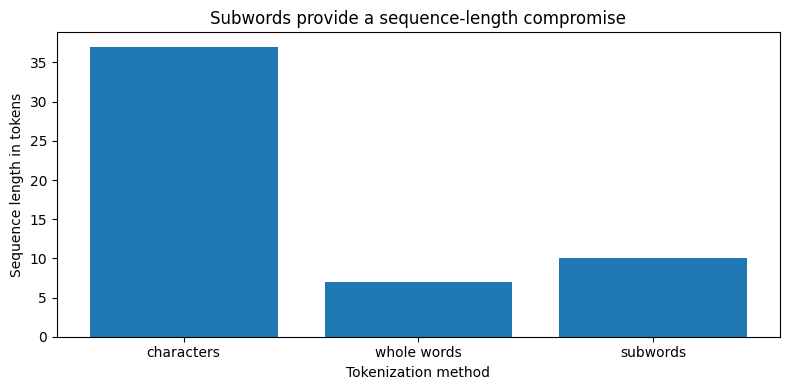

In [11]:
import matplotlib.pyplot as plt  # noqa: I001


method_names = [name for name, tokens in tokenization_results]
token_counts = [len(tokens) for name, tokens in tokenization_results]

plt.figure(figsize=(8, 4))
plt.bar(method_names, token_counts)
plt.xlabel("Tokenization method")
plt.ylabel("Sequence length in tokens")
plt.title("Subwords provide a sequence-length compromise")
plt.tight_layout()
plt.show()

## Compare Handling of an Unseen Whole Word

Assume a word-level vocabulary knows `happy` but has never seen `unhappiness`.

Characters preserve every letter, the whole-word tokenizer loses the word behind `<unknown>`, and the toy subword vocabulary preserves reusable pieces.

In [12]:
test_word = "unhappiness"
known_whole_words = {"happy"}

character_result = tokenize_characters(test_word)
word_result = [
    token if token in known_whole_words else UNKNOWN_TOKEN
    for token in tokenize_words_and_punctuation(test_word)
]
subword_result = split_word_into_subwords(
    test_word,
    subword_vocabulary,
    UNKNOWN_TOKEN,
)

print("Characters:", character_result)
print("Whole word:", word_result)
print("Subwords: ", subword_result)

Characters: ['u', 'n', 'h', 'a', 'p', 'p', 'i', 'n', 'e', 's', 's']
Whole word: ['<unknown>']
Subwords:  ['un', 'happi', 'ness']


This is the main reason subwords are useful.

An unseen word can remain representable when its textual pieces are known.

Many production tokenizers use byte-level or character-level fallbacks so arbitrary input can still be represented without an unknown token.

## Encode Subwords as IDs

Models consume IDs rather than the displayed token strings.

The tokenizer and model must preserve the same vocabulary order so every ID retains the same meaning.

In [13]:
def encode_subwords(
    tokens: list[str],
    token_to_id: dict[str, int],
) -> list[int]:
    return [token_to_id[token] for token in tokens]


def decode_subword_ids(
    token_ids: list[int],
    id_to_token: dict[int, str],
) -> list[str]:
    return [id_to_token[token_id] for token_id in token_ids]


subword_ids = encode_subwords(subword_tokens, subword_to_id)
decoded_subwords = decode_subword_ids(subword_ids, id_to_subword)

assert decoded_subwords == subword_tokens

print("Subwords:", subword_tokens)
print("IDs:     ", subword_ids)
print("Decoded: ", decoded_subwords)

Subwords: ['the', 'child', 'was', 'look', 'ing', 'at', 'un', 'happi', 'ness', '.']
IDs:      [2, 5, 6, 8, 11, 7, 12, 14, 15, 1]
Decoded:  ['the', 'child', 'was', 'look', 'ing', 'at', 'un', 'happi', 'ness', '.']


This assertion verifies a token-level round trip only.

The toy tokenizer cannot reconstruct the original sentence exactly because it lowercases text and discards whitespace boundaries.

Real tokenizer formats include sufficient boundary information for a defined decoding procedure.

## Subwords Are Not Guaranteed Morphemes

Some pieces in this example resemble prefixes, roots, or suffixes.

Learned subword algorithms usually optimize statistics such as frequency or likelihood rather than linguistic analysis.

They may produce fragments that look unintuitive to a reader.

A subword token is a reusable text unit, not a guaranteed grammar lesson.

## What a Learned Tokenizer Must Decide

A practical training algorithm must decide:

- which pieces deserve vocabulary entries;
- how large the vocabulary should be;
- how a word is segmented when several splits are possible;
- how spaces, punctuation, case, Unicode, and bytes are represented; and
- how every token sequence is decoded.

Different choices produce different token IDs and different modeling problems.

A trained model cannot switch tokenizers casually because its parameters are tied to those IDs.

## Takeaways

- Characters avoid whole-word unknowns but create long sequences.
- Whole words shorten sequences but require large vocabularies and fail on unseen forms.
- Subwords reuse pieces across words and often sit between those extremes.
- An unseen whole word can be represented when its component strings are known.
- Subword boundaries depend on the vocabulary and segmentation algorithm.
- Subword pieces are not guaranteed to be linguistically meaningful.
- This hand-written tokenizer demonstrates the idea but does not solve decoding, Unicode, or vocabulary learning.

The next chapter will return to token-ID sequences and build the input-target examples used for next-token prediction.